# Document Exploration

This notebook explores the clinical-trial document corpus before building the retrieval system. We will inspect PDF extraction, page structure, text volume and metadata to make sure the documents are suitable for indexing.

## 1. Load and inspect the first PDF

We will begin by loading one protocol document and checking whether Python can read it correctly. Before building any retrieval system, we need to confirm that the PDF structure, page count, metadata and extracted text are usable.

This first check helps us catch problems such as missing text, broken extraction or incorrect page detection before we process the rest of the corpus.

In [1]:
from pathlib import Path

from pypdf import PdfReader


# Point to the first protocol PDF in the raw data folder
pdf_path = Path("../data/raw/integra_protocol.pdf")

# Confirm that the file exists before trying to read it
print("PDF exists:", pdf_path.exists())

# Load the PDF
reader = PdfReader(pdf_path)

# Check how many pages were detected
print("Number of pages:", len(reader.pages))

# Inspect document-level metadata stored inside the PDF
print("PDF metadata:", reader.metadata)

# Extract text from the first page
first_page_text = reader.pages[0].extract_text()

# Show a short preview so we can inspect the extraction quality
print("\nFirst page text preview:\n")
print(first_page_text[:1500])

PDF exists: True
Number of pages: 11
PDF metadata: {'/Creator': 'Arbortext Advanced Print Publisher 9.1.440/W Unicode', '/Producer': 'Acrobat Distiller 10.1.5 (Windows); modified using iText® 5.3.5 ©2000-2012 1T3XT BVBA (AGPL-version)', '/Title': 'INTEGRA study protocol: primary care intervention in type 2 diabetes patients with poor glycaemic control', '/Keywords': 'Glycated haemoglobin,Clinical inertia,Intervention,Primary care,Type 2 diabetes,Treatment intensification', '/ModDate': "D:20190207143254+01'00'", '/Subject': 'BMC Family Practice, 2019, doi:10.1186/s12875-019-0916-9', '/Author': 'Àngels Molló', '/CreationDate': "D:20190206233919+08'00'"}

First page text preview:

S T U D Y P R O T O C O L Open Access
INTEGRA study protocol: primary care
intervention in type 2 diabetes patients
with poor glycaemic control
Àngels Molló 1,2,3† , Anna Berenguera 4,5† , Esther Rubinat 6,7,8,9, Bogdan Vlacho 10, Manel Mata 11,12,13,14,15,
Josep Franch 16, Bonaventura Bolíbar 17,18 and Dídac Ma

## 2. Extract text from every page

The first page extracted successfully, but we need to check the entire document before using it for retrieval. We will extract each page separately and record simple page-level information such as the page number, text length and extracted text.

Keeping pages separate is important because page provenance will later help us create reliable citations.

In [2]:
import pandas as pd


# Store one record for each page in the PDF
page_records = []

# Go through every page in order
for page_index, page in enumerate(reader.pages):
    # Extract the text from the current page
    page_text = page.extract_text() or ""

    # Store the page number and basic text information
    page_records.append(
        {
            "document_id": "PROTO_003",
            "document_name": "INTEGRA",
            "page_number": page_index + 1,
            "character_count": len(page_text),
            "text": page_text,
        }
    )

# Convert the page records into a table for easier analysis
pages_df = pd.DataFrame(page_records)

# Show the page-level summary without printing all of the text
print(pages_df[["document_id", "document_name", "page_number", "character_count"]])

# Check the overall shape of our page-level dataset
print("\nDataset shape:", pages_df.shape)

   document_id document_name  page_number  character_count
0    PROTO_003       INTEGRA            1             4144
1    PROTO_003       INTEGRA            2             5566
2    PROTO_003       INTEGRA            3             5320
3    PROTO_003       INTEGRA            4             5409
4    PROTO_003       INTEGRA            5             5342
5    PROTO_003       INTEGRA            6             4394
6    PROTO_003       INTEGRA            7             3651
7    PROTO_003       INTEGRA            8             5474
8    PROTO_003       INTEGRA            9             5695
9    PROTO_003       INTEGRA           10             8157
10   PROTO_003       INTEGRA           11             6460

Dataset shape: (11, 5)


## 3. Inspect unusual page lengths

All pages contain a substantial amount of extracted text, but some pages are shorter or longer than others. We will identify the shortest and longest pages and inspect their text to check whether the difference comes from normal document structure or an extraction problem.

In [3]:
# Find the pages with the least and most extracted text
shortest_page = pages_df.loc[pages_df["character_count"].idxmin()]
longest_page = pages_df.loc[pages_df["character_count"].idxmax()]

print("Shortest page:")
print("Page:", shortest_page["page_number"])
print("Characters:", shortest_page["character_count"])
print("\nText preview:\n")
print(shortest_page["text"][:1200])

print("\n" + "=" * 70 + "\n")

print("Longest page:")
print("Page:", longest_page["page_number"])
print("Characters:", longest_page["character_count"])
print("\nText preview:\n")
print(longest_page["text"][:1200])

Shortest page:
Page: 7
Characters: 3651

Text preview:

disagree, agree, strongly agree, N/P). The scores range
in value from 38.6 to 53.0 (on a 0– 100 theoretical point
scale).
Data collection
In the intervention groups (groups 1 and 2), sociodemo-
graphic, anthropometric, clinical, and laboratory vari-
ables are obtained from the clinical history and
anamnesis of the subjects. The data obtained through
the questionnaires are collected during the clinic visit
according to the subjects ’ responses. The variables re-
lated to health care costs are obtained from the SIDIAP
database. In the control groups, all data will be obtained
from the SIDIAP database.
For both groups, variables related to data are collected
as described in Table 1 in the Electronic Case Report
Form (e-CRF), specifically designed for the purpose of
the study.
The consultation with the specialists is carried out in
addition to any others that are deemed necessary, and
the number and frequency of visits is derived from

In [4]:
# Inspect only the longest page without producing a very large output
print("Longest page:", longest_page["page_number"])
print("Characters:", longest_page["character_count"])

print("\nBeginning of page:\n")
print(longest_page["text"][:1000])

print("\nEnd of page:\n")
print(longest_page["text"][-800:])

Longest page: 10
Characters: 8157

Beginning of page:

Pharmaceuticals for Human Use; IG-1: Intervention Group 1; IG-2: Intervention
Group 2; LDL-C: low-density lipoprotein cholesterol; Non-HDL-C: non-high
density lipoprotein cholesterol; PIS: Patient Information Sheet; ICF: Informed
Consent Form; T2DM: Type 2 Diabetes Mellitus
Acknowledgements
We would like to thank Sanofi for contributing to the translation of the
manuscript. Additionally, we would like to thank all of the general practitioners
and nurses.
Funding
The study is partially supported by unrestricted grant from Sanofi. The
study has also intramural suppor t from Institut Universitari d ’Investigació
en Atenció Primària Jordi Gol. The funder does not have any role in
writing the study protocol. This funding source will not have any role
during its execution, analyses, interpretation of the data, or decision to submit
results.
Availability of data and materials
The datasets generated and/or analysed during the current study

## 4. Build the full page-level corpus

The three protocol PDFs have been downloaded and verified successfully. We will now extract every page from the full corpus and combine them into one page-level dataset.

Each page will retain its document ID, document name, filename and page number. Preserving this provenance now is important because the same information will later flow into chunks, retrieval results and citations.

In [7]:
# Load the document provenance information we created earlier
sources_path = Path("../data/metadata/document_sources.csv")
sources_df = pd.read_csv(sources_path)

# Folder containing the original protocol PDFs
raw_data_dir = Path("../data/raw")

# Store one record for every page across all documents
corpus_page_records = []

# Process each document listed in the provenance file
for _, source in sources_df.iterrows():
    pdf_path = raw_data_dir / source["local_filename"]

    # Stop immediately if an expected PDF is missing
    if not pdf_path.exists():
        raise FileNotFoundError(f"Missing PDF: {pdf_path}")

    # Load the current PDF
    pdf_reader = PdfReader(pdf_path)

    # Extract each page while preserving its document provenance
    for page_index, page in enumerate(pdf_reader.pages):
        page_text = page.extract_text() or ""

        corpus_page_records.append(
            {
                "document_id": source["document_id"],
                "document_name": source["short_name"],
                "filename": source["local_filename"],
                "page_number": page_index + 1,
                "character_count": len(page_text),
                "text": page_text,
            }
        )

# Create one combined page-level dataset
corpus_pages_df = pd.DataFrame(corpus_page_records)

# Summarise each document without printing all extracted text
document_summary = (
    corpus_pages_df
    .groupby(["document_id", "document_name"], as_index=False)
    .agg(
        pages=("page_number", "count"),
        total_characters=("character_count", "sum"),
        shortest_page=("character_count", "min"),
        longest_page=("character_count", "max"),
    )
)

print(document_summary)

print("\nCorpus shape:", corpus_pages_df.shape)
print("Total pages:", len(corpus_pages_df))
print("Total extracted characters:", corpus_pages_df["character_count"].sum())

  document_id document_name  pages  total_characters  shortest_page  \
0   PROTO_001       CERTAIN      7             41284           3807   
1   PROTO_002   CARE_STROKE      6             32661           1758   
2   PROTO_003       INTEGRA     11             59612           3651   
3   PROTO_004        LISTEN     13             62287           2463   
4   PROTO_005        THP_TA     15             68339           1293   

   longest_page  
0          8207  
1          7822  
2          8157  
3          7754  
4          7788  

Corpus shape: (52, 6)
Total pages: 52
Total extracted characters: 264183


## 5. Check corpus extraction quality

Before moving on to chunking, we need to make sure the full corpus was extracted reliably. We will check for empty pages, unusually short pages and missing provenance fields.

Short pages are not automatically a problem, but inspecting them helps us identify pages dominated by figures, tables, references or extraction issues.

In [8]:
# Check whether any important provenance fields are missing
metadata_columns = [
    "document_id",
    "document_name",
    "filename",
    "page_number",
]

missing_metadata = corpus_pages_df[metadata_columns].isna().sum()

print("Missing metadata:")
print(missing_metadata)

# Find pages where no text was extracted
empty_pages = corpus_pages_df[
    corpus_pages_df["character_count"] == 0
]

print("\nEmpty pages:", len(empty_pages))

# Use 2,000 characters as an inspection threshold for unusually short pages
# This is only a diagnostic threshold — we are not removing these pages.
short_pages = (
    corpus_pages_df[
        corpus_pages_df["character_count"] < 2000
    ]
    .sort_values("character_count")
)

print("\nPages below 2,000 characters:")
print(
    short_pages[
        [
            "document_id",
            "document_name",
            "page_number",
            "character_count",
        ]
    ]
)

Missing metadata:
document_id      0
document_name    0
filename         0
page_number      0
dtype: int64

Empty pages: 0

Pages below 2,000 characters:
   document_id document_name  page_number  character_count
40   PROTO_005        THP_TA            4             1293
9    PROTO_002   CARE_STROKE            3             1758
45   PROTO_005        THP_TA            9             1989


## 6. Inspect unusually short pages

Only a few pages contain fewer than 2,000 extracted characters. We will inspect these pages to determine whether they are naturally shorter because of tables, figures or document layout, or whether the PDF extraction has missed important text.

We will not remove any pages unless there is clear evidence that the extracted content is unusable.

In [9]:
# Inspect a short preview of every unusually short page
for _, row in short_pages.iterrows():
    print(
        f"{row['document_name']} | "
        f"Page {row['page_number']} | "
        f"{row['character_count']} characters"
    )

    print("\nText preview:\n")
    print(row["text"][:1200])

    print("\n" + "=" * 80 + "\n")

THP_TA | Page 4 | 1293 characters

Text preview:

Page 4 of 15Rahman et al. Trials          (2023) 24:555 
Informed consent and confidentiality issues
Community meetings with village elders, local counse -
lors, and primary health care doctors will be conducted 
in each Union Council, during which information about 
trial activities will be shared. Village cluster-level consent 
will be obtained from the District Health Office responsi-
ble for providing primary health care to Rawalpindi Dis -
trict. At the individual participant level, informed written 
consent will be obtained before screening and baseline 
assessment. The procedure will be undertaken by trained 
researchers.
Information about the rights of trial participants, 
including confidentiality and voluntariness, will be pro -
vided. No personal information will be associated with 
the data of the respective participants; all data will be 
assigned a study identification number, and only this 
number will be used for the stu

In [10]:
# Inspect the remaining short pages with shorter previews
remaining_short_pages = short_pages[
    ~(
        (short_pages["document_name"] == "THP_TA")
        & (short_pages["page_number"] == 4)
    )
]

for _, row in remaining_short_pages.iterrows():
    print(
        f"{row['document_name']} | "
        f"Page {row['page_number']} | "
        f"{row['character_count']} characters"
    )

    print("\nText preview:\n")
    print(row["text"][:700])

    print("\n" + "=" * 70 + "\n")

CARE_STROKE | Page 3 | 1758 characters

Text preview:

3
Sureshkumar K, et al. BMJ Open 2018;8:e020098. doi:10.1136/bmjopen-2017-020098
Open Access
about what intervention could work best for the stroke 
survivors in an Indian context. The eligibility for partici-
pant recruitment in the ‘Care for Stroke Intervention’ trial 
will be based on this uncertainty principle. This approach 
to assess participant eligibility is well established.20
sEttIng
P
articipant recruitment
Participants will be identified using their contact details 
from treatment records for their first ever stroke. These 
details for stroke survivors in India exist in two places. 
Participant diagnosis and details can be collected from the 
hospital records from which an indivi


THP_TA | Page 9 | 1989 characters

Text preview:

Page 9 of 15
Rahman et al. Trials          (2023) 24:555 
 
detection of depression and has a high positive predic -
tive value for the diagnosis of depressive disorder [29] 
and has been used

In [11]:
# Inspect THP_TA page 9 on its own
thp_page_9 = corpus_pages_df[
    (corpus_pages_df["document_name"] == "THP_TA")
    & (corpus_pages_df["page_number"] == 9)
].iloc[0]

print("THP_TA | Page 9")
print("Characters:", thp_page_9["character_count"])

print("\nText preview:\n")
print(thp_page_9["text"][:900])

THP_TA | Page 9
Characters: 1989

Text preview:

Page 9 of 15
Rahman et al. Trials          (2023) 24:555 
 
detection of depression and has a high positive predic -
tive value for the diagnosis of depressive disorder [29] 
and has been used extensively in Pakistan [30].
Symptoms of anxiety
We will use the Generalized Anxiety Disorder 7-Items 
(GAD-7) that scores the seven, DSM-IV symptom-based 
criteria for generalized anxiety disorder on a four-point 
Likert scale from not having the symptom at all to having 
it nearly every day, over the last 2 weeks [31]. The score for 
each item is summed to arrive at a total score. This tool 
also has been extensively used in the study settings [32].
Disability
The WHO disability assessment schedule 2.0 (WHO-
DAS) is a 12-item questionnaire for measuring functional 
impairment over the last 30  days [33]. In addition, two 
items assess the number of days the person was unable to 
work in the past


## 7. Measure corpus text and token volume

Character counts show how much text was extracted, but embedding models and language models process text as tokens. We will estimate the number of tokens on each page and summarise the total token volume for each document.

This gives us a more useful view of corpus size before we begin chunking and embedding the documents.

In [12]:
import tiktoken


# Use a common OpenAI tokenizer to estimate token counts
tokenizer = tiktoken.get_encoding("cl100k_base")

# Count the tokens in each extracted page
corpus_pages_df["token_count"] = corpus_pages_df["text"].apply(
    lambda text: len(tokenizer.encode(text))
)

# Summarise text and token volume for each document
token_summary = (
    corpus_pages_df
    .groupby(["document_id", "document_name"], as_index=False)
    .agg(
        pages=("page_number", "count"),
        total_characters=("character_count", "sum"),
        total_tokens=("token_count", "sum"),
        average_tokens_per_page=("token_count", "mean"),
        shortest_page_tokens=("token_count", "min"),
        longest_page_tokens=("token_count", "max"),
    )
)

# Make the average easier to read
token_summary["average_tokens_per_page"] = (
    token_summary["average_tokens_per_page"].round(1)
)

print(token_summary)

print("\nCorpus total tokens:", corpus_pages_df["token_count"].sum())
print(
    "Average tokens per page:",
    round(corpus_pages_df["token_count"].mean(), 1)
)

  document_id document_name  pages  total_characters  total_tokens  \
0   PROTO_001       CERTAIN      7             41284         10126   
1   PROTO_002   CARE_STROKE      6             32661          7757   
2   PROTO_003       INTEGRA     11             59612         14689   
3   PROTO_004        LISTEN     13             62287         14062   
4   PROTO_005        THP_TA     15             68339         15804   

   average_tokens_per_page  shortest_page_tokens  longest_page_tokens  
0                   1446.6                   948                 2414  
1                   1292.8                   424                 2137  
2                   1335.4                   947                 2278  
3                   1081.7                   494                 1957  
4                   1053.6                   261                 2149  

Corpus total tokens: 62438
Average tokens per page: 1200.7


## 8. Visualise corpus composition

We will visualise the amount of text contributed by each document and the distribution of page token counts across the corpus.

These plots help us check whether one document dominates the dataset and whether page sizes vary substantially before we design the chunking strategy.

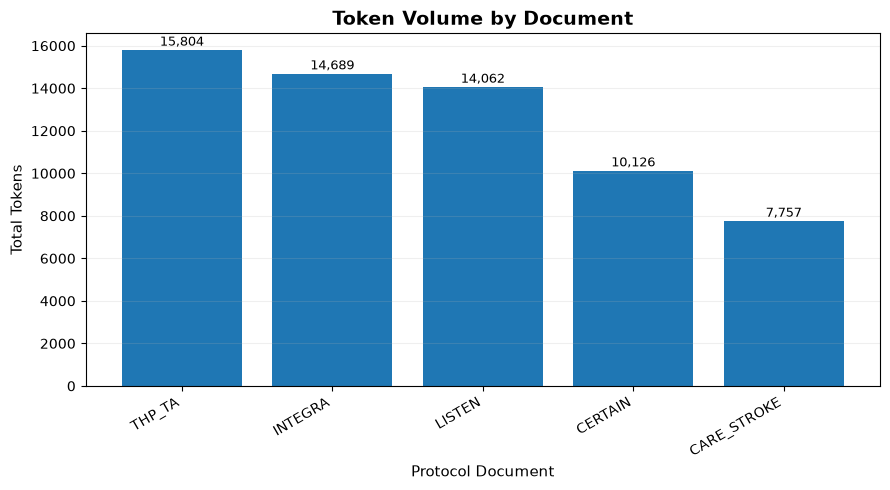

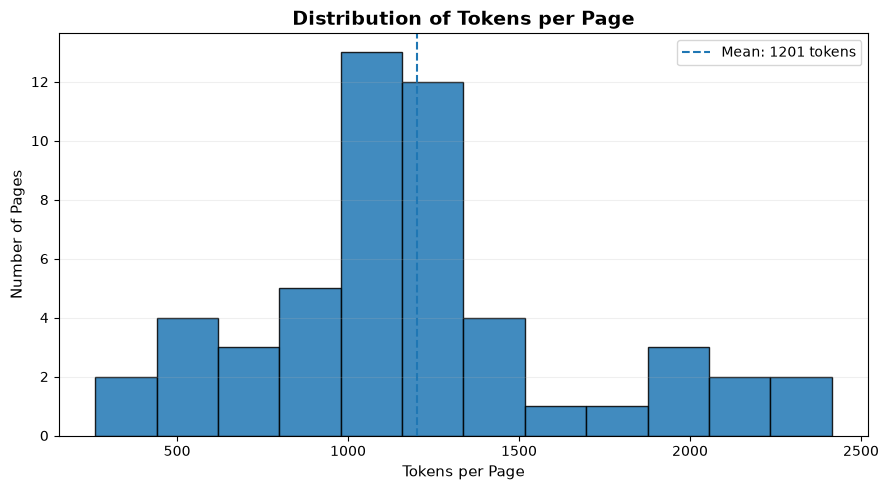

In [15]:
import matplotlib.pyplot as plt


# Calculate the total number of tokens contributed by each document
document_token_counts = (
    corpus_pages_df
    .groupby("document_name")["token_count"]
    .sum()
    .sort_values(ascending=False)
)

# Plot total token contribution by document
plt.figure(figsize=(9, 5))

bars = plt.bar(
    document_token_counts.index,
    document_token_counts.values
)

plt.title(
    "Token Volume by Document",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Protocol Document", fontsize=11)
plt.ylabel("Total Tokens", fontsize=11)

plt.xticks(rotation=30, ha="right")

# Add the token total above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=9
    )

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


# Plot the distribution of token counts across pages
plt.figure(figsize=(9, 5))

plt.hist(
    corpus_pages_df["token_count"],
    bins=12,
    edgecolor="black",
    alpha=0.85
)

plt.title(
    "Distribution of Tokens per Page",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Tokens per Page", fontsize=11)
plt.ylabel("Number of Pages", fontsize=11)

plt.grid(axis="y", alpha=0.2)
average_tokens = corpus_pages_df["token_count"].mean()

plt.axvline(
    average_tokens,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {average_tokens:.0f} tokens"
)

plt.legend()
plt.tight_layout()
plt.show()

## 9. Day 1 findings

The initial corpus contains five public clinical-trial protocol documents with 52 extracted pages and approximately 62,000 tokens.

PDF extraction was successful across the full corpus. No pages were empty and all page-level provenance fields were preserved. A small number of unusually short pages were inspected manually and contained valid protocol content rather than extraction failures.

Some minor PDF formatting artefacts were observed, including split words, hyphenation and repeated page headers. These will be considered during text cleaning rather than modifying the raw extracted data.

The documents also vary in page and token length, which means page boundaries alone are unlikely to provide a consistent chunking strategy.

Overall, the corpus is suitable for the next stage: controlled text cleaning and chunk engineering.

## 10. Save the validated page-level corpus

The extracted pages have passed the Day 1 quality checks, so we will save this validated page-level dataset for the next preprocessing stage.

The raw PDFs remain unchanged. This file is a derived representation containing the extracted text and provenance that Day 2 can load directly.

In [16]:
# Save the validated page-level corpus as JSON Lines
processed_pages_path = Path("../data/processed/corpus_pages.jsonl")

corpus_pages_df.to_json(
    processed_pages_path,
    orient="records",
    lines=True,
    force_ascii=False
)

print("Saved:", processed_pages_path)
print("Rows saved:", len(corpus_pages_df))

Saved: ../data/processed/corpus_pages.jsonl
Rows saved: 52
